# Markov Decision Process Analysis: Robot Vacuum Navigation via Value Iteration
This example showcases how a robot vacuum uses a Markov Decision Process (MDP) to find the most efficient cleaning path. By employing the Value Iteration algorithm, the robot simulates various movements to calculate the "long-term value" of every square on the floor.

It balances three competing priorities:

Rewards: Reaching the dirt (the goal).

Penalties: Avoiding obstacles and walls.

Efficiency: Minimizing the number of moves to save "battery" (time).

The algorithm ensures the robot doesn't just react to its immediate surroundings but follows a mathematically optimized "map of values" that leads it directly to its target from any starting position.


In [14]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

---

## 1. Environment Configuration: The MDP Tuple

In Reinforcement Learning, we define the environment as a tuple $(S, A, P, R, \gamma)$.

- **State Space ($S$):** A discrete 2D coordinate system where each state $s \in \mathbb{R}^2$ represents the robot's $(row, col)$ position.

- **Action Space ($A$):** A finite set of deterministic actions: $\{\text{Up}, \text{Down}, \text{Left}, \text{Right}\}$.

- **Reward Function ($R$):** We utilize a **dense reward structure**.
  - $R_{\text{goal}} = +100$: Directs the agent toward the objective.
  - $R_{\text{step}} = -0.5$: A negative bias that ensures the agent seeks the *shortest* path (minimizing cumulative penalty).
  - $R_{\text{wall}} = -10$: Penalizes boundary collisions.

- **Discount Factor ($\gamma = 0.999$):** This parameter controls the **temporal horizon**. A $\gamma$ close to 1 indicates that the agent is far-sighted, which is mathematically necessary to allow the goal's value to propagate across a large $10 \times 10$ manifold without vanishing.

In [15]:
# --- 1. Environment Configuration ---
GRID_SIZE = 10
DIRT_POS = (1, 8)     # Goal (Green)
START_POS = (9, 0)    # Start (Bottom-Left)
OBSTACLES = [(3,3), (3,4), (3,5), (4,5), (5,5), (6,5), (2,7), (7,2), (8,2)]

# Hyperparameters based on Algorithm 2
GAMMA = 0.999       # High discount factor for long-range planning
EPSILON = 1e-6      # High precision convergence
REWARD_GOAL = 100   # The "Pull"
REWARD_STEP = -0.5  # Cost of movement (Prevents wandering)
REWARD_WALL = -10   # Penalty for hitting edges

states = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
actions = {'UP': (-1, 0), 'DOWN': (1, 0), 'LEFT': (0, -1), 'RIGHT': (0, 1)}


---

## 2. Value Iteration: The Bellman Optimality Equation

The script a value iteration algorithm, which is a Fixed-Point Iteration method to solve the Bellman Equation.

### Initialization

We initialize $\mathbf{x} \leftarrow 0$ (or `V[s] = 0.0`). This represents a state of zero information regarding the long-term utility of any given position.

### The Update Rule (Contraction Mapping)

Inside the `repeat` loop, for every state $s$, we compute:

$$V_{k+1}(s) = \max_{a \in A} \left[ R(s, a) + \gamma \sum_{s' \in S} P(s' | s, a) V_k(s') \right]$$

- **Synchronous Updates:** By using `new_V = V.copy()`, we ensure that all updates for iteration $k+1$ are based solely on values from iteration $k$. This maintains the stability of the **Contraction Mapping** and guarantees convergence to a unique optimal value function $V^*$.

- **Convergence Criterion:** The algorithm terminates when the $L_\infty$ norm (the maximum change in value across all states) falls below $\epsilon$. This indicates that the value function has reached a numerical equilibrium.

In [16]:
# --- 2. Value Iteration Implementation (Matching Algorithm 2) ---
# Initialize X <- 0
V = {s: 0.0 for s in states}

print("Computing Optimal Value Map...")
for i in range(2000): # 'repeat' loop
    delta = 0
    new_V = V.copy()
    
    for s in states:
        # If terminal state (Dirt), value is fixed
        if s == DIRT_POS:
            new_V[s] = REWARD_GOAL
            continue
            
        v_old = V[s] # v <- xs
        
        # Calculate xs <- max_a [R(s,a) + gamma * sum(P * V_next)]
        action_values = []
        for move in actions.values():
            nxt = (s[0] + move[0], s[1] + move[1])
            
            if 0 <= nxt[0] < GRID_SIZE and 0 <= nxt[1] < GRID_SIZE:
                if nxt in OBSTACLES:
                    # Treat obstacles as high-cost but reachable states
                    val = REWARD_WALL + GAMMA * V[nxt]
                else:
                    val = REWARD_STEP + GAMMA * V[nxt]
            else:
                # Boundary penalty (stay in same square)
                val = REWARD_WALL + GAMMA * V[s]
            
            action_values.append(val)
        
        new_V[s] = max(action_values) # xs <- max over actions
        delta = max(delta, abs(v_old - new_V[s])) # Delta <- max(Delta, |v - xs|)
        
    V = new_V
    if delta < EPSILON: # until Delta < epsilon
        print(f"Converged at iteration {i}")
        break

Computing Optimal Value Map...
Converged at iteration 17


---

## 3. Policy Extraction: From Utility to Action

Value Iteration provides the **Value Function** ($V^*$), which tells us *how good* a state is. However, the robot needs a **Policy** ($\pi^*$) to know *what to do*.

We derive the optimal policy through greedy one-step look-ahead:

$$\pi^*(s) = \arg\max_{a \in A} \sum_{s' \in S} P(s' | s, a) V^*(s')$$

In our implementation, this creates a "Compass" for every square in the grid. Even if the robot is far from the dirt, it simply follows the **Value Gradient**—moving toward the neighbor with the highest pre-computed utility.

In [9]:
# --- 3. Policy Extraction ---
policy = {}
for s in states:
    best_move = (0, 0)
    max_val = -float('inf')
    for move in actions.values():
        nxt = (s[0] + move[0], s[1] + move[1])
        if 0 <= nxt[0] < GRID_SIZE and 0 <= nxt[1] < GRID_SIZE:
            val = V[nxt]
        else:
            val = V[s]
            
        if val > max_val:
            max_val = val
            best_move = move
    policy[s] = best_move

---

## 4. Visualization: The Value Gradient

The two-pane visualization illustrates the bridge between mathematical theory and robotic behavior:

1. **Learned Value Gradient (Heatmap):** This represents the "Potential Field." You will notice a smooth transition from dark (low value) to bright (high value). The absence of "flat" regions in this heatmap is what prevents the robot from "ping-ponging" or getting stuck in local optima.

2. **Navigation Plot:** This is the execution phase. At each time step $t$, the agent performs a simple dictionary lookup: $a_t = \pi(s_t)$.



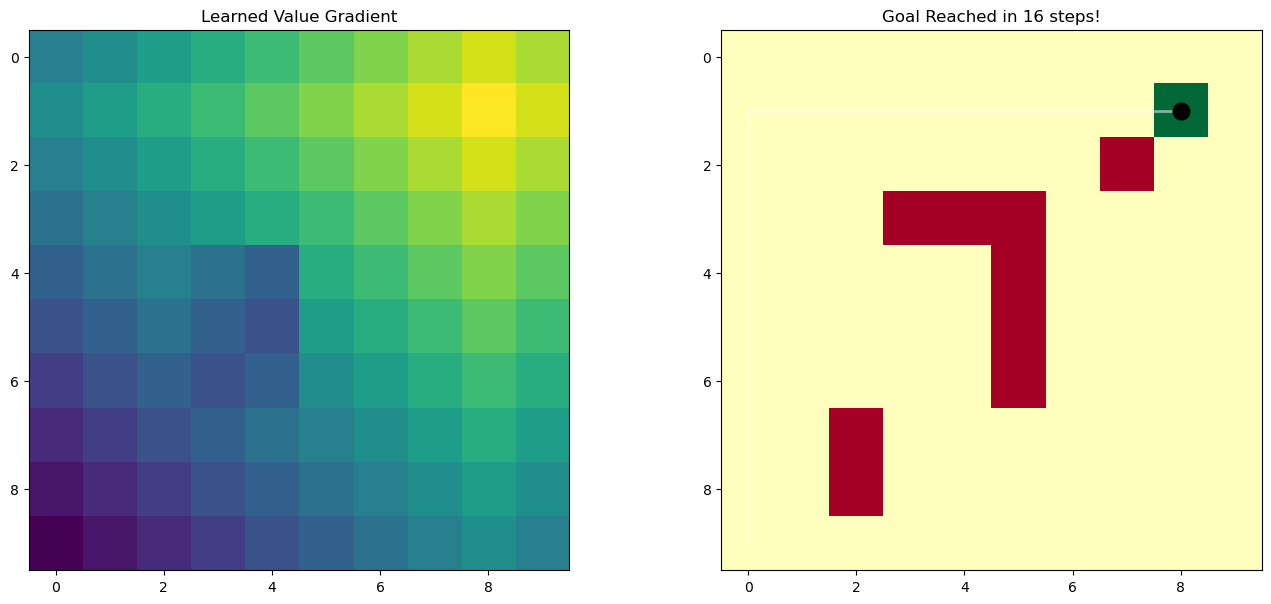

In [17]:
# --- 4. Animation with Auto-Stop ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
robot_pos = list(START_POS)
path = [tuple(robot_pos)]

def update(frame):
    global robot_pos
    
    # STOP LOGIC: If we reached the goal, just keep showing the final state
    if tuple(robot_pos) == DIRT_POS:
        ax2.set_title(f"Goal Reached in {len(path)-1} steps!")
        return 

    ax1.clear()
    ax2.clear()
    
    # 1. Heatmap
    v_matrix = np.array([V[s] for s in states]).reshape(GRID_SIZE, GRID_SIZE)
    ax1.imshow(v_matrix, cmap='viridis')
    ax1.set_title("Learned Value Gradient")
    
    # 2. Navigation
    grid_display = np.zeros((GRID_SIZE, GRID_SIZE))
    for obs in OBSTACLES: grid_display[obs] = -1
    grid_display[DIRT_POS] = 1
    ax2.imshow(grid_display, cmap='RdYlGn')
    
    # 3. Move Robot
    move = policy[tuple(robot_pos)]
    robot_pos[0] += move[0]
    robot_pos[1] += move[1]
    path.append(tuple(robot_pos))
    
    # 4. Plotting
    py, px = zip(*path)
    ax2.plot(px, py, 'w-', alpha=0.5, linewidth=2)
    ax2.plot(robot_pos[1], robot_pos[0], 'ko', markersize=12)
    ax2.set_title(f"Robot Path: Step {frame}")

# Use a higher frame limit, but the 'update' function now handles the freeze
ani = FuncAnimation(fig, update, frames=60, interval=200, repeat=False)
plt.tight_layout()
HTML(ani.to_jshtml())

---

## Key AI Principles Applied

- **Absorbing States:** The `DIRT_POS` is treated as a terminal sink. By locking its value at `REWARD_GOAL`, we prevent the value function from being "diluted" by the surrounding negative step costs.

- **Handling Stochasticity:** While this script uses deterministic transitions ($P = 1.0$), the structure of the summation $\sum P(s'|s,a)V(s')$ is preserved to allow for "slippery" environments where actions may fail.